In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import time

import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.utils import shuffle
from sklearn.model_selection import ParameterSampler 
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import learning_curve
from tensorflow.keras.utils import to_categorical

import tensorflow as tf
from tensorflow.keras.models import Sequential
from scikeras.wrappers import KerasClassifier
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from itertools import cycle
from tqdm import tqdm

In [2]:
# Go two levels up from DeepLearning to reach Bookify
BASE_DIR = os.getcwd()

# Correct path to Database/Cleaned_Datasets
DATA_DIR = os.path.normpath(os.path.join(BASE_DIR, '..', '..', 'Database', 'Cleaned_Datasets'))


#Define Model directory
MODEL_DIR = os.path.normpath(os.path.join(BASE_DIR, '..', '..', 'Models'))

In [3]:
SENTIMENT_DATA_PATH = os.path.join(DATA_DIR, "processed_reviews_with_embeddings_and_sentiment.csv")

# Load the cleaned review dataset
df = pd.read_csv(SENTIMENT_DATA_PATH)

In [4]:
df.head()

,review_id,book_id,user_id,review_text,ratings,review_date,source,author,book_name,cleaned_text,cleaned_tokens,lemmatized_tokens,tokens,w2v_vector,vader_score,sentiment
0,1,B0033UV8HI,A3HHXRELK8BHQG,Jace Rankin may be short but hes nothing to me...,3,2010-09-02,Amazon,Unknown,Unknown,jace rankin may be short but hes nothing to me...,jace rankin may short hes nothing mess man hau...,"['jace', 'rankin', 'may', 'be', 'short', 'but'...",jace rankin may be short but he nothing to mes...,[-0.04869615 0.20041396 -0.05382273 -0.050893...,0.9661,positive
1,2,B002HJV4DE,A2RGNZ0TRF578I,Great short read I didnt want to put it down s...,5,2013-10-08,Amazon,Unknown,Unknown,great short read i didnt want to put it down s...,great short didnt want put one sitting sex sce...,"['great', 'short', 'read', 'i', 'didnt', 'want...",great short read i didnt want to put it down s...,[ 0.00399838 0.14723115 -0.11875696 -0.129964...,0.9600,positive
2,3,B002ZG96I4,A3S0H2HV6U1I7F,Ill start by saying this is the first of four ...,3,2014-04-11,Amazon,Unknown,Unknown,ill start by saying this is the first of four ...,ill start saying first four books wasnt expect...,"['ill', 'start', 'by', 'saying', 'this', 'is',...",ill start by saying this is the first of four ...,[-0.03159767 0.17707181 -0.06081005 -0.023490...,0.7650,positive
3,4,B002QHWOEU,AC4OQW3GZ919J,Aggie is Angela Lansbury who carries pocketboo...,3,2014-07-05,Amazon,Unknown,Unknown,aggie is angela lansbury who carries pocketboo...,aggie angela lansbury carries pocketbooks inst...,"['aggie', 'is', 'angela', 'lansbury', 'who', '...",aggie is angela lansbury who carry pocketbook ...,[-0.00847244 0.2208083 -0.07991216 0.034060...,-0.1280,negative
4,5,B001A06VJ8,A3C9V987IQHOQD,I did not expect this type of book to be in li...,4,2012-12-31,Amazon,Unknown,Unknown,i did not expect this type of book to be in li...,expect type library pleased find price right,"['i', 'did', 'not', 'expect', 'this', 'type', ...",i did not expect this type of book to be in li...,[-0.04064076 0.14156152 -0.02016523 -0.025961...,0.4404,positive


In [5]:
# Show basic info and first few rows
print(df.shape)
print(df['sentiment'].value_counts())

(74907, 16)
sentiment
positive    56107
negative    16286
neutral      2514
Name: count, dtype: int64


In [6]:
# Encode sentiment labels
label_encoder = LabelEncoder()
df['sentiment_encoded'] = label_encoder.fit_transform(df['sentiment'])

In [7]:
text = df['cleaned_text'].astype(str).values
label = df['sentiment_encoded'].values

print(f"Total samples: {len(text)}")
print(f"Sample text: {text[0]}")
print(f"Sample label: {label[0]}")

Total samples: 74907
Sample text: jace rankin may be short but hes nothing to mess with as the man who was just hauled out of the saloon by the undertaker knows now hes a famous bounty hunter in oregon in the s who when he shot the man in the saloon just finished a years long quest to avenge his sisters murder and is now trying to figure out what to do next when the snottynosed farm boy he just rescued from a gang of bullies offers him money to kill a man who forced him off his ranch he reluctantly agrees to bring the man to justice but not to kill him outright but first he needs to tell his sisters widower the newskyla kyle springer bailey has been riding the trails and sleeping on the ground for the past month while trying to find jace she wants revenge on the man who killed her husband and took her ranch amongst other crimes and shes not so keen on the detour jace wants to take but she realizes shes out of options so she hides behind her boy persona as best she can and tries to keep

In [8]:
# Split data for training/validation
X_train_texts, X_val_texts, y_train, y_val = train_test_split(
    text, label, test_size=0.2, random_state=42, stratify=label
)


In [9]:
print("Vectorizing text data for Random Forest ")
tfidf = TfidfVectorizer(max_features=10000)
X_train_tfidf = tfidf.fit_transform(X_train_texts)
X_val_tfidf = tfidf.transform(X_val_texts)
print("TF-IDF vectorization completed.")

Vectorizing text data for Random Forest 
TF-IDF vectorization completed.


In [10]:
print("\n Random Forest Hyperparameter Tuning")

# Define param grid
rf_param_dist = {
    'n_estimators': [50, 100, 150],
    'max_depth': [5, 10, 15],              # Restrict max_depth to prevent overfitting
    'min_samples_split': [5, 10, 20],      # Larger splits reduce overfitting
    'min_samples_leaf': [2, 5, 10],        # Ensure minimum samples per leaf
    'max_features': ['sqrt', 'log2'],      # Limit number of features considered at each split
    'bootstrap': [True]                    # Use bootstrapping for variance reduction
}
# Create parameter sampler
n_iter = 10
param_sampler = list(ParameterSampler(rf_param_dist, n_iter=n_iter, random_state=42))

best_acc = 0
best_model = None
best_params = None

print(" Starting Random Forest hyperparameter tuning...\n")
start_time = time.time()

# Loop with tqdm
for params in tqdm(param_sampler, desc="Tuning RF", ncols=100):
    model = RandomForestClassifier(**params, random_state=42, n_jobs=-1)
    scores = cross_val_score(model, X_train_tfidf, y_train, cv=5, scoring='accuracy')
    mean_acc = scores.mean()
    if mean_acc > best_acc:
        best_acc = mean_acc
        best_model = model
        best_params = params

elapsed = time.time() - start_time
print(f"\nRandom Forest tuning done in {elapsed:.2f} seconds")
print("Best RF Params:", best_params)


 Random Forest Hyperparameter Tuning
 Starting Random Forest hyperparameter tuning...



Tuning RF: 100%|████████████████████████████████████████████████████| 10/10 [06:40<00:00, 40.01s/it]


Random Forest tuning done in 400.33 seconds
Best RF Params: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 15, 'bootstrap': True}


In [11]:
# Retrain on full training data
best_rf_model = RandomForestClassifier(**best_params, random_state=42)
best_rf_model.fit(X_train_tfidf, y_train)

# Evaluate best model
y_pred_rf = best_rf_model.predict(X_val_tfidf)
rf_acc = accuracy_score(y_val, y_pred_rf)
print(f"Random Forest Validation Accuracy: {rf_acc:.4f}")


Random Forest Validation Accuracy: 0.7607


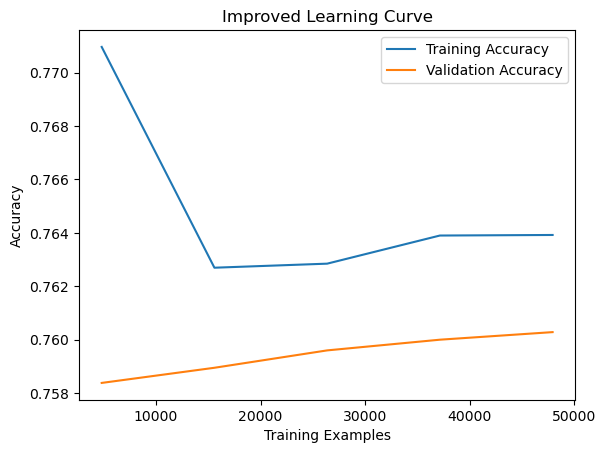

In [12]:
# Plot RF Learning Curve

train_sizes, train_scores, val_scores = learning_curve(
    best_rf_model, X_train_tfidf, y_train, cv=5,
    train_sizes=np.linspace(0.1, 1.0, 5), scoring='accuracy', n_jobs=-1
)

train_scores_mean = train_scores.mean(axis=1)
val_scores_mean = val_scores.mean(axis=1)

plt.plot(train_sizes, train_scores_mean, label='Training Accuracy')
plt.plot(train_sizes, val_scores_mean, label='Validation Accuracy')
plt.title("Improved Learning Curve")
plt.xlabel("Training Examples")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

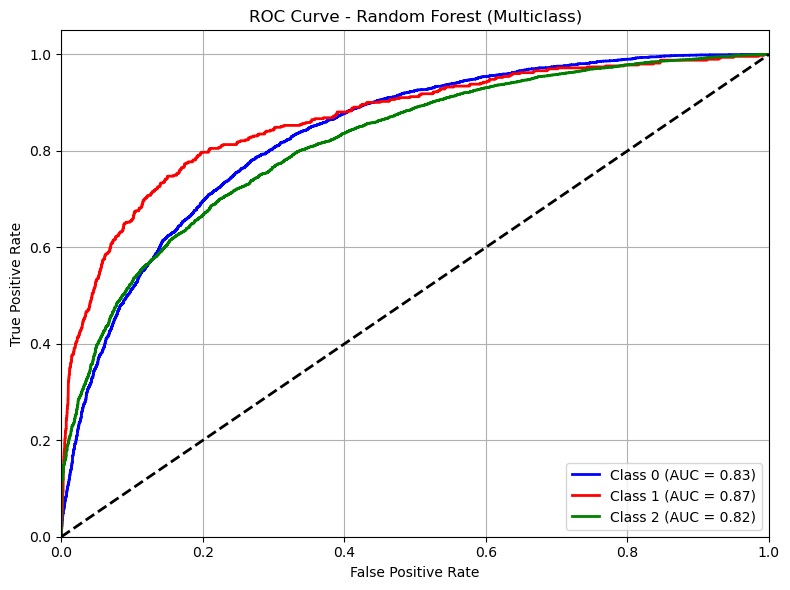

In [13]:
# Binarize the output labels
classes = sorted(list(set(y_train)))  # or list(best_rf_model.classes_)
y_val_bin = label_binarize(y_val, classes=classes)
n_classes = y_val_bin.shape[1]

# Get predicted probabilities
y_score = best_rf_model.predict_proba(X_val_tfidf)

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_val_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
colors = cycle(['blue', 'red', 'green', 'purple', 'orange'])
plt.figure(figsize=(8, 6))
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'Class {classes[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest (Multiclass)')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

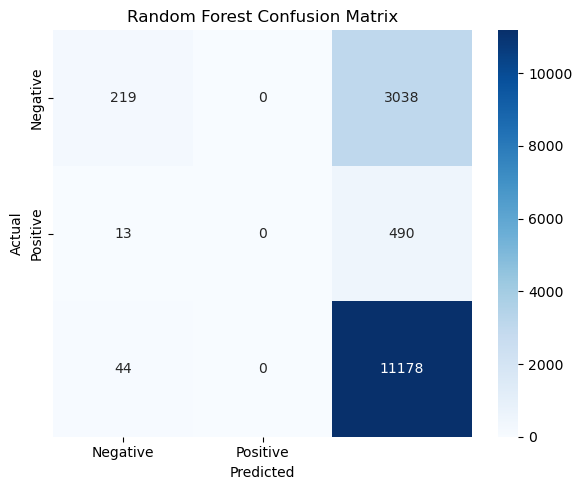

In [14]:
# Compute Confusion Matrix
cm_rf = confusion_matrix(y_val, y_pred_rf)

# Define class names (update if your sentiment classes are different)
class_names = ['Negative', 'Positive']  # or ['Negative', 'Neutral', 'Positive'] if multiclass

plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [15]:
# Save the best random forest model
rf_model_path = os.path.join(MODEL_DIR, 'final_rf_model.pkl')
joblib.dump(best_rf_model, rf_model_path)
print(f"Random Forest model saved at: {rf_model_path}")

Random Forest model saved at: C:\Users\HP\Desktop\Bookify\Models\final_rf_model.pkl


In [17]:
max_words = 10000
max_len = 100  

# Tokenize and pad
tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(X_train_texts)

X_train_seq = tokenizer.texts_to_sequences(X_train_texts)
X_val_seq = tokenizer.texts_to_sequences(X_val_texts)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
X_val_pad = pad_sequences(X_val_seq, maxlen=max_len)

# Encode training and validation labels to integers
label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)
y_val_enc = label_encoder.transform(y_val)

# Convert to one-hot encoded labels (for 3 sentiment classes)
y_train_cat = to_categorical(y_train_enc, num_classes=3)
y_val_cat = to_categorical(y_val_enc, num_classes=3)

In [19]:
import keras_tuner as kt

# Build model for tuner
def build_model(hp):
    model = Sequential()
    model.add(Embedding(input_dim=max_words, output_dim=64, input_length=max_len))
    
    units = hp.Choice('units', [32, 64, 128])
    model.add(LSTM(units))
    
    dropout = hp.Float('dropout', 0.2, 0.5, step=0.1)
    model.add(Dropout(dropout))
    
    model.add(Dense(3, activation='softmax'))  # 3 sentiment classes
    
    learning_rate = hp.Choice('learning_rate', [1e-2, 1e-3, 1e-4])
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# Initialize tuner
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=5,
    executions_per_trial=1,
    directory='lstm_tuning_dir',
    project_name='sentiment_lstm_tuning'
)

# Early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

# Search
tuner.search(
    X_train_pad, y_train_cat,
    epochs=10,
    validation_data=(X_val_pad, y_val_cat),
    callbacks=[early_stop]
)

# Retrieve best model
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"Best units: {best_hp.get('units')}")
print(f"Best dropout: {best_hp.get('dropout')}")
print(f"Best learning rate: {best_hp.get('learning_rate')}")

Reloading Tuner from lstm_tuning_dir\sentiment_lstm_tuning\tuner0.json
Best units: 32
Best dropout: 0.4
Best learning rate: 0.001


In [21]:
from tensorflow.keras.optimizers import Adam

# Define model
final_model = Sequential()
final_model.add(Embedding(input_dim=max_words, output_dim=64, input_length=max_len))
final_model.add(LSTM(32))
final_model.add(Dropout(0.4))
final_model.add(Dense(3, activation='softmax'))

# Compile model
final_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

# Train model
history = final_model.fit(
    X_train_pad, y_train_cat,
    validation_data=(X_val_pad, y_val_cat),
    epochs=10,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/10
1873/1873 ━━━━━━━━━━━━━━━━━━━━ 322s 150ms/step - accuracy: 0.7582 - loss: 0.6098 - val_accuracy: 0.8294 - val_loss: 0.4193
Epoch 2/10
1873/1873 ━━━━━━━━━━━━━━━━━━━━ 63s 34ms/step - accuracy: 0.8482 - loss: 0.3856 - val_accuracy: 0.8471 - val_loss: 0.3912
Epoch 3/10
1873/1873 ━━━━━━━━━━━━━━━━━━━━ 69s 36ms/step - accuracy: 0.8808 - loss: 0.3149 - val_accuracy: 0.8440 - val_loss: 0.4030
Epoch 4/10
1873/1873 ━━━━━━━━━━━━━━━━━━━━ 72s 38ms/step - accuracy: 0.9061 - loss: 0.2602 - val_accuracy: 0.8245 - val_loss: 0.4580


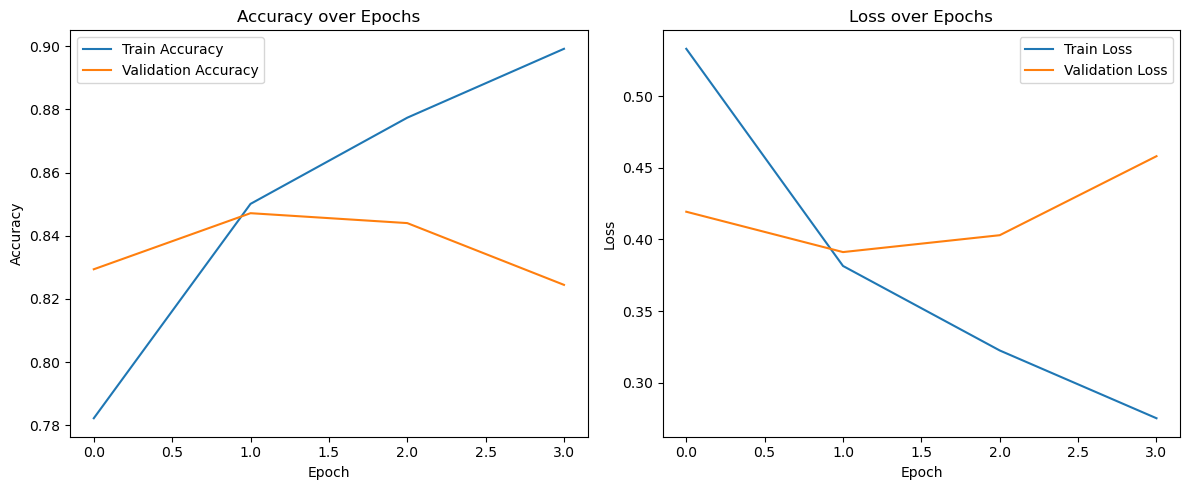

In [22]:
# Plot training & validation accuracy and loss
plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step


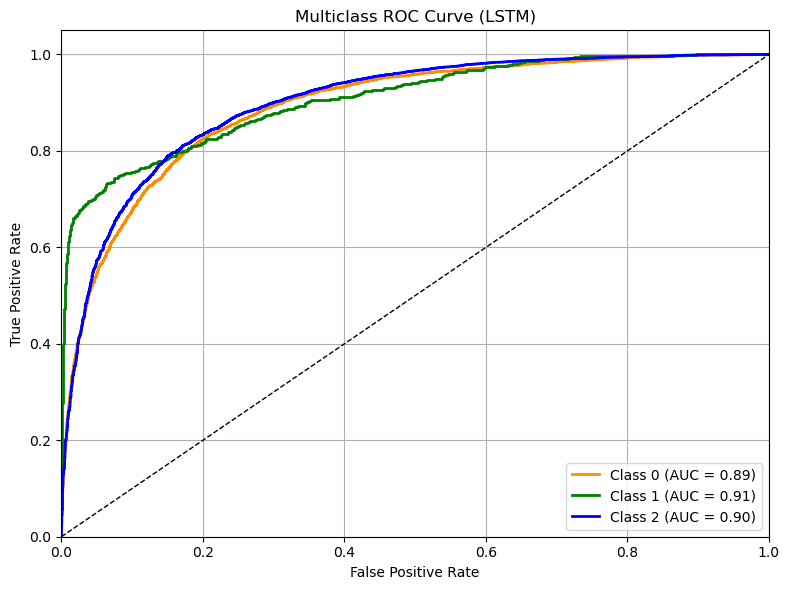

In [24]:
# Predict probabilities for validation set
y_pred_probs = final_model.predict(X_val_pad)

# Binarize the labels for ROC
y_val_bin = label_binarize(y_val_enc, classes=[0, 1, 2])

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
n_classes = 3

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_val_bin[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
colors = cycle(['darkorange', 'green', 'blue'])
plt.figure(figsize=(8, 6))
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'Class {label_encoder.classes_[i]} (AUC = {roc_auc[i]:0.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass ROC Curve (LSTM)')
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

In [25]:
# Evaluate
val_loss, val_acc = final_model.evaluate(X_val_pad, y_val_cat)
print(f"Validation Accuracy: {val_acc:.4f}")

# Predict
y_pred_probs = final_model.predict(X_val_pad)
y_pred = np.argmax(y_pred_probs, axis=1)

# Convert class labels to strings (e.g., ["0", "1", "2"])
target_names = [str(label) for label in label_encoder.classes_]

# Classification report
print(classification_report(y_val_enc, y_pred, target_names=target_names))

469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.8470 - loss: 0.3864
Validation Accuracy: 0.8471
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step
              precision    recall  f1-score   support

           0       0.75      0.54      0.63      3257
           1       0.68      0.60      0.64       503
           2       0.87      0.95      0.91     11222

    accuracy                           0.85     14982
   macro avg       0.77      0.70      0.73     14982
weighted avg       0.84      0.85      0.84     14982



469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step


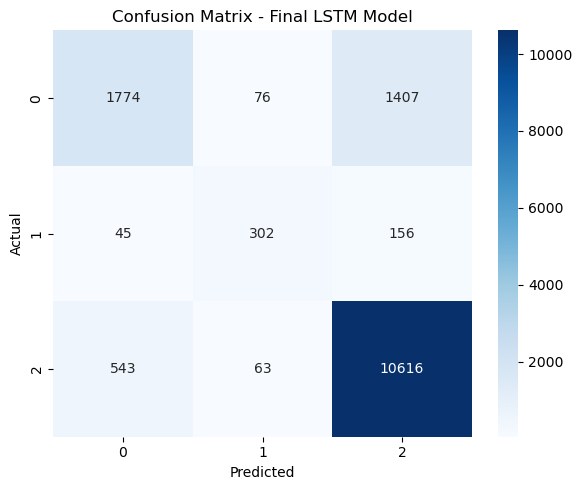

In [26]:
# Predict on validation data
y_pred_probs = final_model.predict(X_val_pad)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_val_cat, axis=1)  # Convert one-hot back to integer labels

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix - Final LSTM Model')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [27]:
# Save model
lstm_model_path = os.path.join(MODEL_DIR, 'final_lstm_model.h5')

# Save the trained final model
final_model.save(lstm_model_path)

print(f"LSTM model saved at: {lstm_model_path}")

LSTM model saved at: C:\Users\HP\Desktop\Bookify\Models\final_lstm_model.h5


In [28]:

# Summary: Compare model accuracies

print(" Model Accuracy Summary")
print(f"Random Forest Accuracy: {rf_acc:.4f}")
print(f"LSTM Accuracy: {val_acc:.4f}")


 Model Accuracy Summary
Random Forest Accuracy: 0.7607
LSTM Accuracy: 0.8471


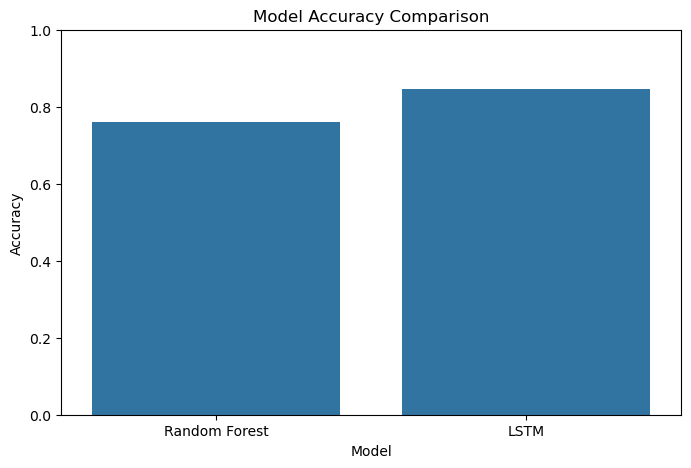

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Create summary DataFrame
summary_df = pd.DataFrame({
    'Model': ['Random Forest', 'LSTM'],
    'Accuracy': [rf_acc, val_acc]
})

# Plot the accuracy comparison
plt.figure(figsize=(8, 5))
sns.barplot(x='Model', y='Accuracy', data=summary_df)
plt.ylim(0, 1)
plt.title('Model Accuracy Comparison')
plt.show()

In [31]:
print("Best LSTM Hyperparameters:")
print(f"  units: {best_hp.get('units')}")
print(f"  dropout: {best_hp.get('dropout')}")
print(f"  learning_rate: {best_hp.get('learning_rate')}\n")

print("Best Random Forest Hyperparameters:")
print(best_params)


Best LSTM Hyperparameters:
  units: 32
  dropout: 0.4
  learning_rate: 0.001

Best Random Forest Hyperparameters:
{'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 15, 'bootstrap': True}


In [35]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.metrics import precision_score, recall_score, f1_score

comparison_df = pd.DataFrame({
    "Model": ["LSTM", "Random Forest"],
    "Accuracy": [val_acc, best_acc],
    "Precision": [
        precision_score(y_val_enc, y_pred, average='weighted'),
        precision_score(y_val_enc, y_pred_rf, average='weighted')
    ],
    "Recall": [
        recall_score(y_val_enc, y_pred, average='weighted'),
        recall_score(y_val_enc, y_pred_rf, average='weighted')
    ],
    "F1-score": [
        f1_score(y_val_enc, y_pred, average='weighted'),
        f1_score(y_val_enc, y_pred_rf, average='weighted')
    ]
})
print(comparison_df)


           Model  Accuracy  Precision    Recall  F1-score
0           LSTM  0.847150   0.839172  0.847150  0.838356
1  Random Forest  0.760284   0.741835  0.760713  0.672792


Random Forest Metrics:
              precision    recall  f1-score   support

           0       0.79      0.07      0.12      3257
           1       0.00      0.00      0.00       503
           2       0.76      1.00      0.86     11222

    accuracy                           0.76     14982
   macro avg       0.52      0.35      0.33     14982
weighted avg       0.74      0.76      0.67     14982



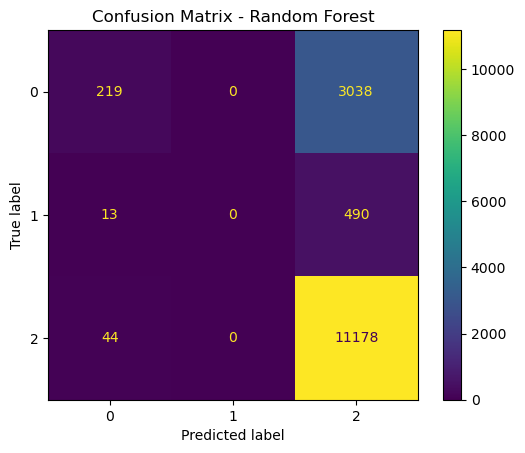

LSTM Metrics:
              precision    recall  f1-score   support

           0       0.75      0.54      0.63      3257
           1       0.68      0.60      0.64       503
           2       0.87      0.95      0.91     11222

    accuracy                           0.85     14982
   macro avg       0.77      0.70      0.73     14982
weighted avg       0.84      0.85      0.84     14982



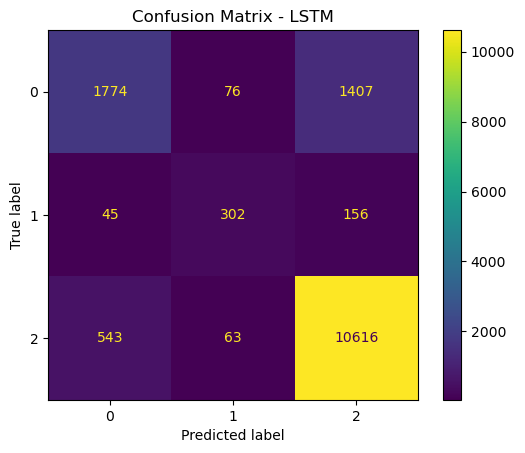

In [39]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

# Convert class labels to strings (if numeric)
target_names = [str(cls) for cls in label_encoder.classes_]

print("Random Forest Metrics:")
print(classification_report(y_val_enc, y_pred_rf, target_names=target_names))
ConfusionMatrixDisplay.from_predictions(y_val_enc, y_pred_rf)
plt.title("Confusion Matrix - Random Forest")
plt.show()

print("LSTM Metrics:")
print(classification_report(y_val_enc, y_pred, target_names=target_names))
ConfusionMatrixDisplay.from_predictions(y_val_enc, y_pred)
plt.title("Confusion Matrix - LSTM")
plt.show()